# Analyse des Données Météo : EDA & Analyse Statistique
**Projet Data Engineering Force N | Groupe A** 
**Fichier source :** `data/processed/weather_processed_enriched.csv` (via `analysis/paths.py`) 

---
 **1. EDA** et **2. Analyse statistique** 


## 1. Chargement des données

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

PALETTE = ["#1F5673", "#2E9599", "#E8A33D", "#C1554B", "#6B7C93"]

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().resolve().parents[1]))
from analysis.paths import OUTPUT_EDA, ensure_enriched_csv, ensure_output_dirs

ensure_output_dirs()

df = pd.read_csv(ensure_enriched_csv(), parse_dates=["date_time", "date"])
print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()


Dimensions : 96429 lignes x 17 colonnes


,date_time,summary,precip_type,temperature_c,apparent_temperature_c,humidity,wind_speed_km_per_h,wind_bearing_degrees,visibility_km,pressure_millibars,daily_summary,date,year,month,day,hour,day_of_week
0,2005-12-31 23:00:00+00:00,Partly Cloudy,rain,0.577778,-4.050000,0.89,17.1143,140.0,9.9820,1016.66,Mostly cloudy throughout the day.,2005-12-31,2005,12,31,23,Saturday
1,2006-01-01 00:00:00+00:00,Mostly Cloudy,rain,1.161111,-3.238889,0.85,16.6152,139.0,9.9015,1016.15,Mostly cloudy throughout the day.,2006-01-01,2006,1,1,0,Sunday
2,2006-01-01 01:00:00+00:00,Mostly Cloudy,rain,1.666667,-3.155556,0.82,20.2538,140.0,9.9015,1015.87,Mostly cloudy throughout the day.,2006-01-01,2006,1,1,1,Sunday
3,2006-01-01 02:00:00+00:00,Overcast,rain,1.711111,-2.194444,0.82,14.4900,140.0,9.9015,1015.56,Mostly cloudy throughout the day.,2006-01-01,2006,1,1,2,Sunday
4,2006-01-01 03:00:00+00:00,Mostly Cloudy,rain,1.183333,-2.744444,0.86,13.9426,134.0,9.9015,1014.98,Mostly cloudy throughout the day.,2006-01-01,2006,1,1,3,Sunday


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96429 entries, 0 to 96428
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   date_time               96429 non-null  datetime64[us, UTC]
 1   summary                 96429 non-null  str                
 2   precip_type             96429 non-null  str                
 3   temperature_c           96429 non-null  float64            
 4   apparent_temperature_c  96429 non-null  float64            
 5   humidity                96429 non-null  float64            
 6   wind_speed_km_per_h     96429 non-null  float64            
 7   wind_bearing_degrees    96429 non-null  float64            
 8   visibility_km           96429 non-null  float64            
 9   pressure_millibars      96429 non-null  float64            
 10  daily_summary           96429 non-null  str                
 11  date                    96429 non-null  datetime64[u

## 2. Contrôle de la qualité des données reçues

Avant toute analyse, on vérifie que les données livrées par le pipeline sont bien conformes à ce qui a été annoncé (0 valeur manquante, 0 doublon).

In [3]:
print("Valeurs manquantes :")
print(df.isnull().sum().sum(), "valeur(s) manquante(s) au total")
print(f"\nDoublons : {df.duplicated().sum()}")
print(f"\nPériode couverte : {df['date_time'].min()} -> {df['date_time'].max()}")
print(f"\nColonnes disponibles ({df.shape[1]}) :")
print(list(df.columns))


Valeurs manquantes :
0 valeur(s) manquante(s) au total

Doublons : 0

Période couverte : 2005-12-31 23:00:00+00:00 -> 2016-12-31 22:00:00+00:00

Colonnes disponibles (17) :
['date_time', 'summary', 'precip_type', 'temperature_c', 'apparent_temperature_c', 'humidity', 'wind_speed_km_per_h', 'wind_bearing_degrees', 'visibility_km', 'pressure_millibars', 'daily_summary', 'date', 'year', 'month', 'day', 'hour', 'day_of_week']


In [4]:
# Ajout d'une colonne saison (non fournie par le pipeline mais utile pour l'analyse)
season_map = {12: "Hiver", 1: "Hiver", 2: "Hiver",
              3: "Printemps", 4: "Printemps", 5: "Printemps",
              6: "Été", 7: "Été", 8: "Été",
              9: "Automne", 10: "Automne", 11: "Automne"}
df["season"] = df["month"].map(season_map)
season_order = ["Hiver", "Printemps", "Été", "Automne"]
df["season"] = pd.Categorical(df["season"], categories=season_order, ordered=True)
print("Colonne 'season' ajoutée.")
df[["date_time", "year", "month", "season"]].head(3)


Colonne 'season' ajoutée.


,date_time,year,month,season
0,2005-12-31 23:00:00+00:00,2005,12,Hiver
1,2006-01-01 00:00:00+00:00,2006,1,Hiver
2,2006-01-01 01:00:00+00:00,2006,1,Hiver


## 3. EDA : Résumé des données

In [5]:
num_cols = ["temperature_c", "apparent_temperature_c", "humidity",
            "wind_speed_km_per_h", "visibility_km", "pressure_millibars"]
df[num_cols].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
temperature_c,96429.0,11.93,9.55,-21.82,4.68,12.00,18.84,39.91
apparent_temperature_c,96429.0,10.85,10.70,-27.72,2.31,12.00,18.84,39.34
humidity,96429.0,0.73,0.20,0.00,0.60,0.78,0.89,1.00
wind_speed_km_per_h,96429.0,10.81,6.91,0.00,5.83,9.97,14.14,63.85
visibility_km,96429.0,10.35,4.19,0.00,8.34,10.05,14.81,16.10
pressure_millibars,96429.0,1016.82,7.78,973.78,1012.12,1016.56,1021.17,1046.38


In [6]:
print("Répartition Precip Type :")
print((df["precip_type"].value_counts(normalize=True) * 100).round(2).astype(str) + " %")
print("\nRépartition Summary (top 8) :")
print(df["summary"].value_counts().head(8))


Répartition Precip Type :
precip_type
rain       88.36 %
snow       11.11 %
unknown     0.54 %
Name: proportion, dtype: str

Répartition Summary (top 8) :
summary
Partly Cloudy               31726
Mostly Cloudy               28094
Overcast                    16597
Clear                       10873
Foggy                        7148
Breezy and Overcast           528
Breezy and Mostly Cloudy      516
Breezy and Partly Cloudy      386
Name: count, dtype: int64


summary
Partly Cloudy               31726
Mostly Cloudy               28094
Overcast                    16597
Clear                       10873
Foggy                        7148
Breezy and Overcast           528
Breezy and Mostly Cloudy      516
Breezy and Partly Cloudy      386
Name: count, dtype: int64


### 3.1 Distributions (analyse univariée)

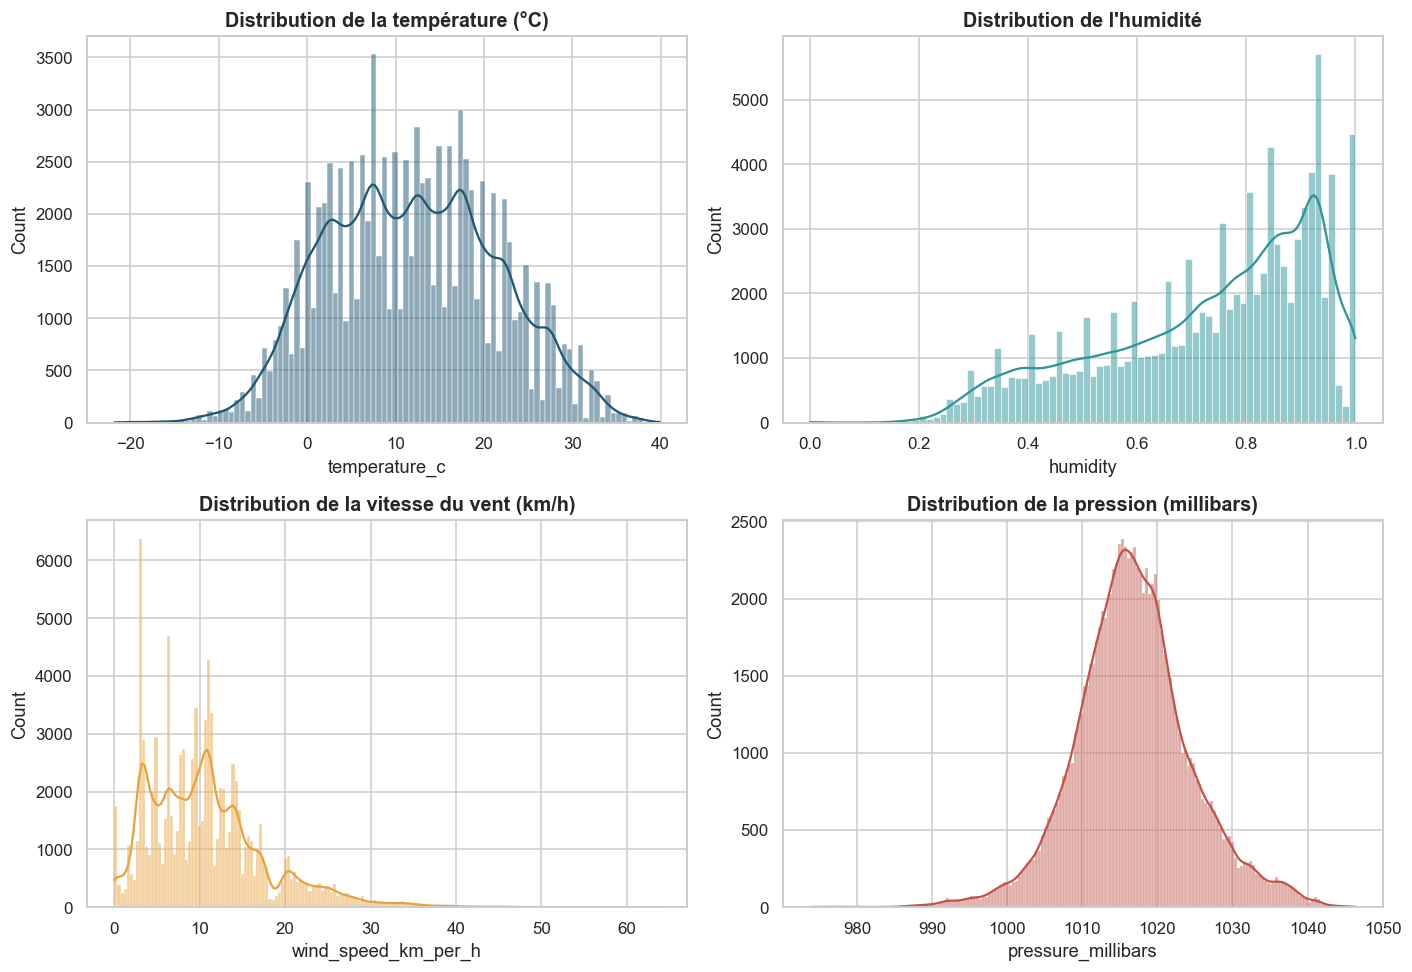

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df["temperature_c"], kde=True, ax=axes[0,0], color=PALETTE[0])
axes[0,0].set_title("Distribution de la température (°C)")

sns.histplot(df["humidity"], kde=True, ax=axes[0,1], color=PALETTE[1])
axes[0,1].set_title("Distribution de l'humidité")

sns.histplot(df["wind_speed_km_per_h"], kde=True, ax=axes[1,0], color=PALETTE[2])
axes[1,0].set_title("Distribution de la vitesse du vent (km/h)")

sns.histplot(df["pressure_millibars"], kde=True, ax=axes[1,1], color=PALETTE[3])
axes[1,1].set_title("Distribution de la pression (millibars)")

plt.tight_layout()
plt.savefig(OUTPUT_EDA / "fig_univariee.png", bbox_inches="tight")
plt.show()


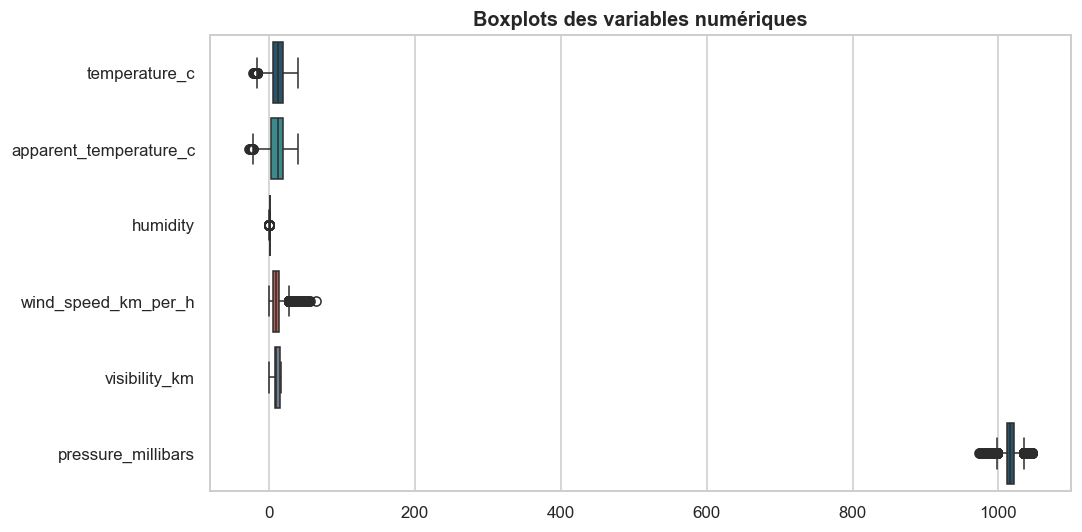

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df[num_cols], orient="h", palette=PALETTE, ax=ax)
ax.set_title("Boxplots des variables numériques")
plt.tight_layout()
plt.savefig(OUTPUT_EDA / "fig_boxplots.png", bbox_inches="tight")
plt.show()


### 3.2 : Tendances (analyse temporelle)

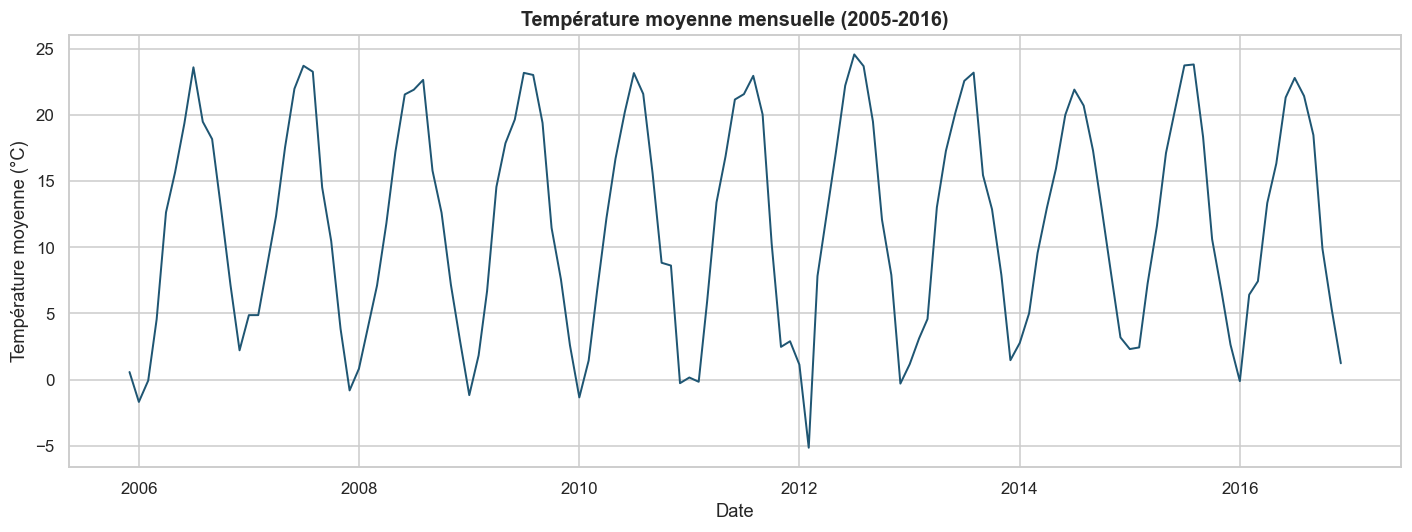

In [9]:
monthly = df.groupby(["year", "month"], observed=True)["temperature_c"].mean().reset_index()
monthly["date"] = pd.to_datetime(monthly["year"].astype(str) + "-" + monthly["month"].astype(str) + "-01")
monthly = monthly.sort_values("date")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly["date"], monthly["temperature_c"], color=PALETTE[0], linewidth=1.3)
ax.set_title("Température moyenne mensuelle (2005-2016)")
ax.set_ylabel("Température moyenne (°C)")
ax.set_xlabel("Date")
plt.tight_layout()
plt.savefig(OUTPUT_EDA / "fig_trend_monthly.png", bbox_inches="tight")
plt.show()


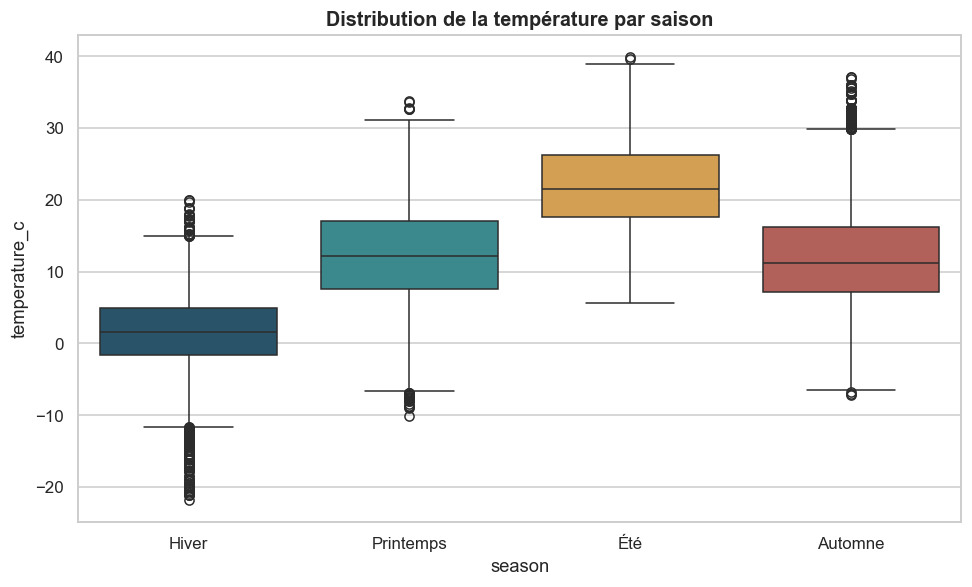

In [10]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=df, x="season", y="temperature_c", order=season_order, palette=PALETTE, ax=ax)
ax.set_title("Distribution de la température par saison")
plt.tight_layout()
plt.savefig(OUTPUT_EDA / "fig_box_season.png", bbox_inches="tight")
plt.show()


## 4. EDA :Relations entre variables (analyse bivariée)

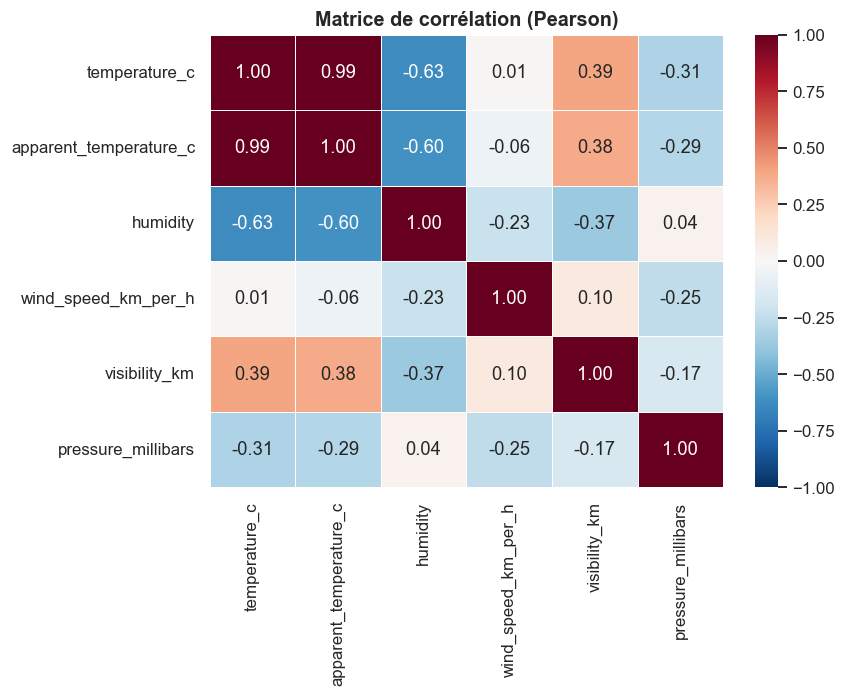

In [11]:
corr = df[num_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title("Matrice de corrélation (Pearson)")
plt.tight_layout()
plt.savefig(OUTPUT_EDA / "fig_heatmap.png", bbox_inches="tight")
plt.show()


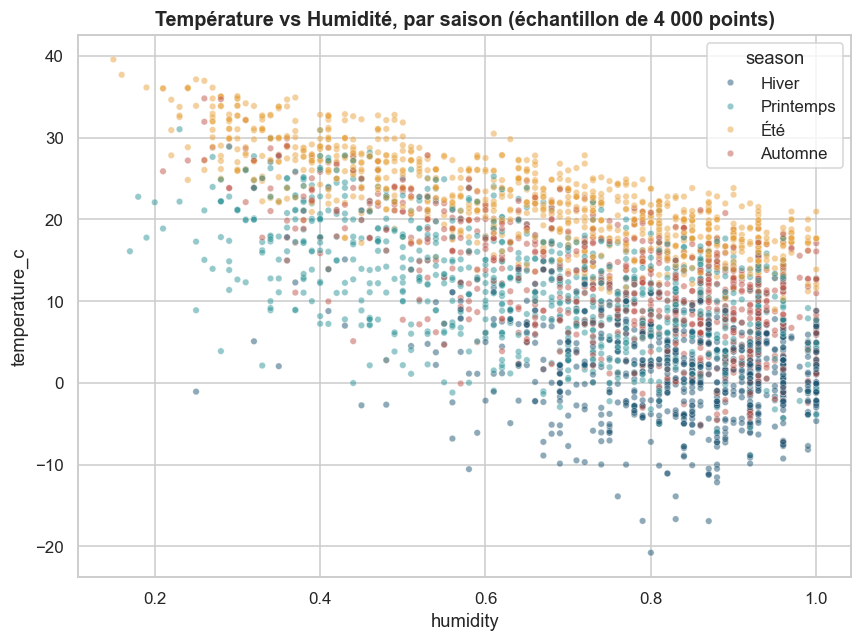

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
sample = df.sample(4000, random_state=42)
sns.scatterplot(data=sample, x="humidity", y="temperature_c", hue="season",
                 palette=PALETTE, alpha=0.5, ax=ax, s=18)
ax.set_title("Température vs Humidité, par saison (échantillon de 4 000 points)")
plt.tight_layout()
plt.savefig(OUTPUT_EDA / "fig_scatter_temp_humidity.png", bbox_inches="tight")
plt.show()


## 5. Analyse statistique : tests d'hypothèses

Deux questions concrètes, avec preuve statistique à l'appui :
1. **La température et l'humidité sont-elles corrélées de façon significative ?** 
2. **La température moyenne diffère-t-elle significativement selon la saison ?** 


In [13]:
# 1. Corrélation de Pearson : Température vs Humidité
r, p_value = stats.pearsonr(df["temperature_c"], df["humidity"])
print(f"Coefficient de corrélation de Pearson : r = {r:.3f}")
print(f"p-value : {p_value:.2e}")
significativite = "significative" if p_value < 0.05 else "non significative"
force = "forte" if abs(r) >= 0.6 else "modérée" if abs(r) >= 0.3 else "faible"
sens = "négative" if r < 0 else "positive"
print(f"=> Corrélation {sens} {force}, statistiquement {significativite} (p < 0.05 : {p_value < 0.05}).")


Coefficient de corrélation de Pearson : r = -0.632
p-value : 0.00e+00
=> Corrélation négative forte, statistiquement significative (p < 0.05 : True).


In [14]:
# 2. ANOVA à un facteur : Température moyenne selon la saison
groupes = [df.loc[df["season"] == s, "temperature_c"] for s in season_order]
f_stat, p_value_anova = stats.f_oneway(*groupes)

print(f"Statistique F : {f_stat:.2f}")
print(f"p-value : {p_value_anova:.2e}")
print(f"=> Différence {'statistiquement significative' if p_value_anova < 0.05 else 'non significative'} entre les saisons.")

print("\nMoyennes de température par saison :")
print(df.groupby("season", observed=True)["temperature_c"].mean().round(2).reindex(season_order))


Statistique F : 43542.20
p-value : 0.00e+00
=> Différence statistiquement significative entre les saisons.

Moyennes de température par saison :
season
Hiver         1.52
Printemps    12.18
Été          22.02
Automne      11.80
Name: temperature_c, dtype: float64


In [15]:
# Test complémentaire : la vitesse du vent diffère-t-elle selon le type de précipitation (pluie vs neige) ?
pluie = df.loc[df["precip_type"] == "rain", "wind_speed_km_per_h"]
neige = df.loc[df["precip_type"] == "snow", "wind_speed_km_per_h"]

t_stat, p_value_t = stats.ttest_ind(pluie, neige, equal_var=False)
print(f"Test t (vent : pluie vs neige) : t = {t_stat:.2f}, p-value = {p_value_t:.2e}")
print(f"=> Différence {'statistiquement significative' if p_value_t < 0.05 else 'non significative'} entre les deux groupes.")
print(f"\nVent moyen par temps de pluie : {pluie.mean():.2f} km/h")
print(f"Vent moyen par temps de neige : {neige.mean():.2f} km/h")


Test t (vent : pluie vs neige) : t = 22.11, p-value = 1.75e-106
=> Différence statistiquement significative entre les deux groupes.

Vent moyen par temps de pluie : 10.97 km/h
Vent moyen par temps de neige : 9.48 km/h


## 6. Détection des valeurs aberrantes résiduelles (méthode IQR)

In [18]:
def detect_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    borne_inf, borne_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = series[(series < borne_inf) | (series > borne_sup)]
    return outliers, borne_inf, borne_sup

for col in ["wind_speed_km_per_h", "pressure_millibars", "visibility_km"]:
    outliers, low, high = detect_outliers_iqr(df[col])
    pct = 100 * len(outliers) / len(df)
    print(f"{col:25s} -> {len(outliers):5d} outliers ({pct:.2f}%) | bornes IQR : [{low:.1f} ; {high:.1f}]")


wind_speed_km_per_h       ->  3028 outliers (3.14%) | bornes IQR : [-6.6 ; 26.6]
pressure_millibars        ->  3328 outliers (3.45%) | bornes IQR : [998.5 ; 1034.7]
visibility_km             ->     0 outliers (0.00%) | bornes IQR : [-1.4 ; 24.5]


**Note** : ces outliers résiduels (vitesse du vent, pression) sont des valeurs extrêmes mais physiquement plausibles en météo (rafales, dépressions) : le pipeline ne les a pas supprimés car il ne s'agit pas d'erreurs de données, contrairement aux pressions à 0 mb qui étaient impossibles et ont déjà été corrigées en amont.

## 7. Tableau de synthèse : KPI clés

In [20]:
kpi = pd.DataFrame({
    "Indicateur": ["Température moyenne", "Température min", "Température max",
                   "Humidité moyenne", "Vent moyen", "Pression moyenne",
                   "Nombre de relevés", "Période"],
    "Valeur": [f"{df['temperature_c'].mean():.1f} °C",
               f"{df['temperature_c'].min():.1f} °C",
               f"{df['temperature_c'].max():.1f} °C",
               f"{df['humidity'].mean()*100:.0f} %",
               f"{df['wind_speed_km_per_h'].mean():.1f} km/h",
               f"{df['pressure_millibars'].mean():.1f} mb",
               f"{len(df):,}".replace(",", " "),
               f"{df['date_time'].min().date()} → {df['date_time'].max().date()}"]
})
kpi


,Indicateur,Valeur
0,Température moyenne,11.9 °C
1,Température min,-21.8 °C
2,Température max,39.9 °C
3,Humidité moyenne,73 %
4,Vent moyen,10.8 km/h
5,Pression moyenne,1016.8 mb
6,Nombre de relevés,96 429
7,Période,2005-12-31 → 2016-12-31


## 8. **Résultats statistiques prouvés**
- Corrélation Température / Humidité : **r = -0,63** (p < 0,001) : corrélation négative forte et significative.
- ANOVA saisonnière : **F = 43 542** (p < 0,001) : différence hautement significative de température entre les 4 saisons. Moyennes : Hiver 1,5°C, Printemps 12,2°C, Été 22,0°C, Automne 11,8°C.